In [1]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [2]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

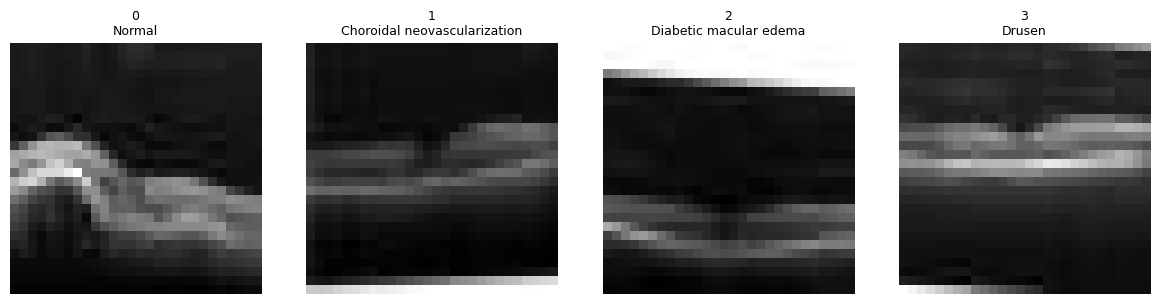

In [3]:
#For our first dimensionality reduction method we will explore clustering something we didn't use at all in milestone 1

import matplotlib.pyplot as plt
label_names = {
    0: "Normal",
    1: "Choroidal neovascularization",
    2: "Diabetic macular edema",
    3: "Drusen"
}

plt.figure(figsize=(12, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    idx = np.flatnonzero(train_labels == i)[0]
    plt.imshow(train_images[idx], cmap="gray")
    plt.title(f"{i}\n{label_names[i]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

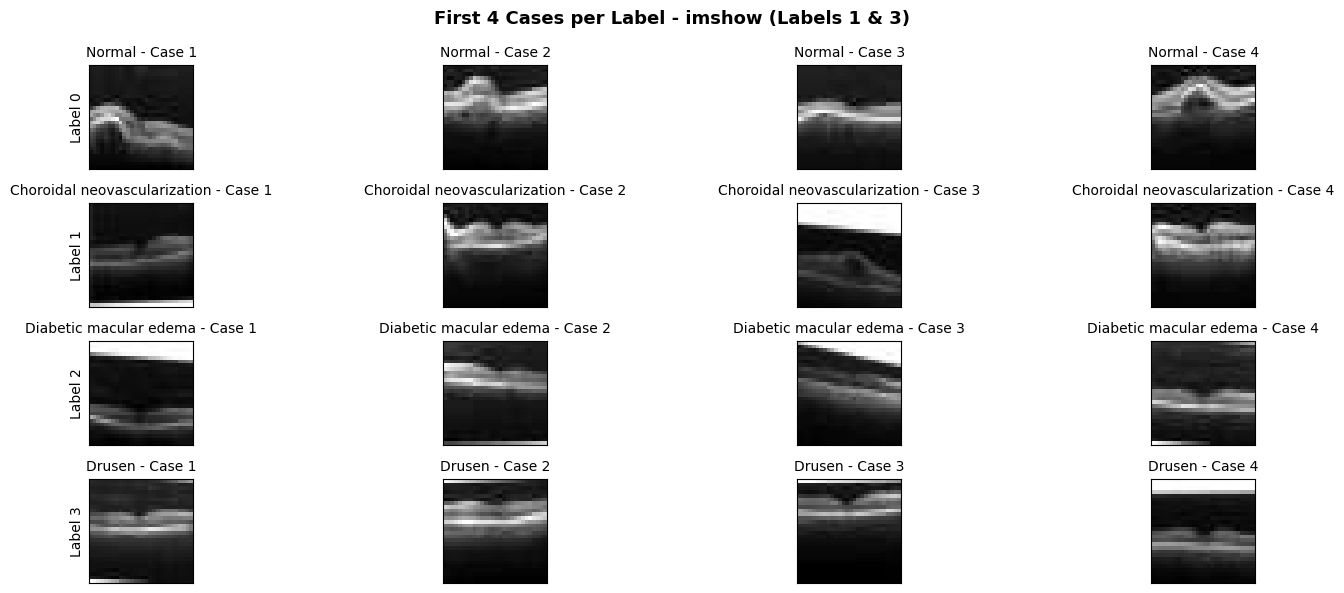

In [4]:
label_0_idx = np.where(train_labels == 0)[:4]
label_1_idx = np.where(train_labels == 1)[:4]
label_2_idx = np.where(train_labels == 2)[:4]
label_3_idx = np.where(train_labels == 3)[:4]

cases = {
    0: train_images[label_0_idx],
    1: train_images[label_1_idx],
    2: train_images[label_2_idx],
    3:train_images[label_3_idx]}

fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(16, 6)
)

for row_idx, label in enumerate([0, 1, 2, 3]):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]

        im = ax.imshow(
            cases[label][col_idx],
            cmap="gray",
        )

        ax.set_title(f'{label_names[label]} - Case {col_idx + 1}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        if col_idx == 0:
            ax.set_ylabel(f'Label {label}', fontsize=10)

plt.suptitle(f"First 4 Cases per Label - imshow (Labels 1 & 3)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()





Observations:
1. Normal Case is often presents a curve, is bright, and often has a distinct white line.
2. Choroidal neovascularization seems to fall into two categories. Darkened with a blackened spot and almost lip shaped white pieces. It's hard to go off of anything here. Not many assumptions will be made to avoid generalization error.
3. Diabetic Macular Edemea appears roughly straighter, with a slight decrement in the middle.
4. Drusen seems very very similar to Diabetic Macular Edema and some cases of Choroidal neovascularization with perhaps a more consistent shape & color.

The biggest thing: For classification purpose it seems like what we truly care about is the shape and color intensity of these paths. If there is a way we can, isolate or represent this information in less pixels we could cut down the potential number of features considerably while still maintaining good results. How would we do this though? Not sure. Will table this discussion for now and focus on a method learned in class: K-Means.

In [5]:
def flatten_data(X):
    '''Flattens a 3D array into a 2D one'''
    new_arr = X.reshape(X.shape[0], -1)
    return new_arr



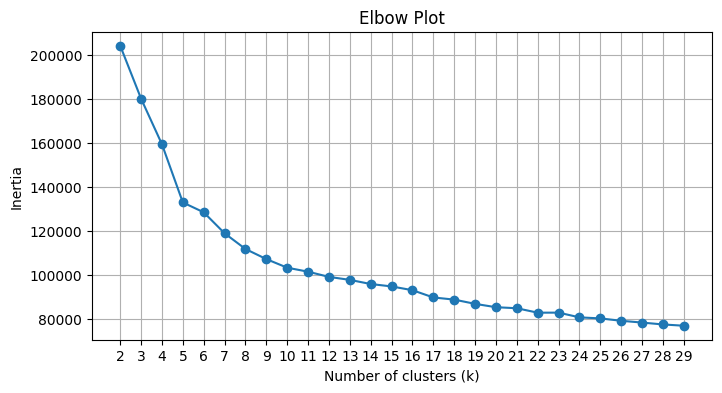

In [6]:
#Let us begin to train a k-means algorithmn on this dataset.
#An algorithm we have learned about and has potential.
#For starters let us explore what an optimal number of clusters may be.
#Since this is just a pass to test out k-means as a strategy
#intead of using the more compuationally expensive sillhoute score method
#We will simply calculate the interias and attempt to find an elbow
#this is meant to be a rough pass if potential is shown we can explore a more optimal k in the future
from sklearn.cluster import MiniBatchKMeans, KMeans
from utils import flattener
#See milestone 1 for flattener implementation
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

inertias = []
k_range = range(2, 30)

for k in k_range:
    pipe = Pipeline([
        ("flat", flattener),
        ("normal", MinMaxScaler()),
        ("kmean", MiniBatchKMeans(n_clusters=k,
                                   random_state=42,
                                   batch_size=2048))
        #To reduce computation time we will
        #use minibatchKmeans
        #for the actual canidate pipeline we will use Kmeans
        #batch_size=2048 as I was getting warning
        #on a memory leak
    ])
    pipe.fit(val_images)
    inertias.append(pipe.named_steps["kmean"].inertia_)

plt.figure(figsize=(8 , 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.xticks(k_range)
plt.grid(True)
plt.show()



The Elbow occurs pretty concretely at 4. This doesn't garuntee best results. But is enough for an initial pass

In [7]:
from sklearn.svm import LinearSVC
from utils import stratified_subset, train_eval_model, median, avg_2x2_pool
from sklearn.preprocessing import FunctionTransformer
#Once again see milestone 1 for code for utility functions


km_pipe = Pipeline([
    ("flat", flattener),
    ("scale", MinMaxScaler()),
    ("kmeans", KMeans(
        n_clusters=4,
        random_state=32,
    )),
    ("model", LinearSVC(
        dual=True,
        max_iter=1000
        ))
])

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)

train_eval_model(
    name="Kmeans (n_clusters=4)",
    model=km_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)



Model: Kmeans (n_clusters=4)
Training Time: 2.772
acc: 0.4835
prec:0.5687
recall:0.4835



c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


(0.4835, 0.5687067514367166, 0.4835)

In [8]:
from utils import build_pipelines

pipes = build_pipelines()

for name, pipe in pipes.items():
    train_eval_model(
        name=name,
        model=pipe,
        x_tr=x_tr,
        y_tr=y_tr,
        x_va=x_va,
        y_va=y_va
    )


c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model: Baseline (784px)
Training Time: 136.207
acc: 0.6530
prec:0.6080
recall:0.6530



c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model: Avg pool (196px)
Training Time: 50.021
acc: 0.6515
prec:0.6815
recall:0.6515

Model: Avg pool (49px)
Training Time: 16.773
acc: 0.6365
prec:0.6523
recall:0.6365



c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

Model: Max pool (196px)
Training Time: 49.881
acc: 0.6395
prec:0.6842
recall:0.6395



c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model: PCA 50
Training Time: 15.293
acc: 0.5840
prec:0.6641
recall:0.5840

Model: Generated features
Training Time: 3.168
acc: 0.5380
prec:0.6255
recall:0.5380



c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model: Median then PCA
Training Time: 97.400
acc: 0.6580
prec:0.6952
recall:0.6580



Compared to our baseline model and the Kmeans Canidate performs pretty solidly worse than the other models, though has a MUCH faster trainin time. Given the size of this dataset this shows solid potential. The amount of clusters could be increased to show marginal gains, perhaps could transform the data in a way that would make the data more seperable into different clusters (not sure how exactly would do this, experimentation would be required. then use kmeans for better results.) Overall Kmeans shows potential just due to its extreme training efficiency

Hypothesis of canidate model. The first things to note is which dimensionality reduction canidate had the best results. As of present, median filtering the averaging into a 14x14 pool is our best canidate in terms of accuracy, precision, & recall. Making it the most logical decision to use for our First Canidate

What models show potential given this data/preprocessing method?

Logistic Regression: Should train quickly but outside of that cannot think of a reason to use it over other models.
Naive Bayes: Can Handle Higher Dimensional Data. Outside of that not optimistic.
SVC: If we assume data is linearly separable this is the most natural choice

With this method of feature reduction, Even after smoothing we still end up with a quite large feature space (14x14 picture) -> 196 features. It makes the most sense to use a model such as SVC or Naive Bayes that can handle Linearly separable data very well, as with this high dimensionality, odds are it is.

Outside of Training Time I don't see much reason to use Logistic Regression or Naive Bayes especially because the features in this case are almost certainly NOT independent. (a bright image pixel probably means a brighter neighboring pixel. Naive Bayes is likely not the best option.)

As much as I am generally attracted to Random Forest/Decision Trees. I feel that RandomForests Are generally just a very powerful model and on the chance that there decision boundary isn't linear it is almost certainly the best choice. The One Worry Would be Training Time.

So we have our Model Canidates:
1. SVC or variant
2. Logistic Regressor or Variant
3. RandomForest Classifier

We will first explore a RandomForestClassifier as it shows the most consistent potential and is the easiest to test/implement in Scikit-Learn.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_canidate = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            #scaling not needed for DTCs
            ("model",
             RandomForestClassifier(
                 max_features=None, #setting this for simplicity on comparison
                 n_jobs=-1
             ))
        ])
#For this initial sweep we are going to leave hyperparameters mostly
#at default values


train_eval_model(
    name="Random Forest Canidate",
    model=rf_canidate,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

Model: Random Forest Canidate
Training Time: 127.708
acc: 0.7175
prec:0.7427
recall:0.7175



(0.7175, 0.7427091712671143, 0.7175)

Solid Results let us compare it to a Bagging Classifier of SVCs to sort of mimic a Ranom Forest

In [10]:
from sklearn.ensemble import BaggingClassifier

bagging_svc = BaggingClassifier(
    estimator=LinearSVC(
        dual=False,
        max_iter=4000,
    ),
    n_estimators=100,
    max_samples=0.1,
    bootstrap=True,
    bootstrap_features=True,
    n_jobs=-1
) #These hyperparameters are identical to the Random Forest
#The only difference. Is the underlying classifier

svc_canidate = Pipeline([
    ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            #scaling not needed for DTCs
            ("model", bagging_svc)
])

train_eval_model(
    name="SVC Canidate",
    model=svc_canidate,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

Model: SVC Canidate
Training Time: 1047.847
acc: 0.6545
prec:0.7033
recall:0.6545



(0.6545, 0.7032595771748763, 0.6545)

The SVC Candiate has disappoint results as professor prediced. While actually doing fairly well in percision the weak SVCs came up quite short in terms of accuracy.

In [11]:
x_tr.shape

(22000, 28, 28)

In [12]:
#Lets compare a RandomizedSearch now
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 4, 8, 16],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": ["sqrt", "log2", 0.1, 0.25, None],
}

search = RandomizedSearchCV(
    estimator=rf_canidate,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring="accuracy", #Most balanced metric to compare
    n_jobs=-1,
    verbose=2,
    refit=True
)

train_eval_model(
    name="RandomSearchRandomForest",
    model=search,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Model: RandomSearchRandomForest
Training Time: 5987.810
acc: 0.7150
prec:0.7419
recall:0.7150



(0.715, 0.7419257938394885, 0.715)

In [13]:
search.best_params_

{'model__max_depth': None,
 'model__max_features': None,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 12,
 'model__n_estimators': 441}

After doing some fitting we've hit roughly 70% in accurcy, precision & Recall the best observed for all benchmarks so far. With further tuning even better results could be possible. Nothing to get too excited about so far. I'm sure we can do much better than 70%. Interestingly prioritized going with an extremely deep tree with single leaf nodes. This indicates that the decision rule it found is likely non linear (maybe pointing to SVC not being a great fit) OR we have overfit the model and need to regularize that can be tested for later though.

It has been brought to my attention that RandomForests are an elementary classifier. We will switch to a stacking classifier to instead incorporating the models that have potential.

As a reminder the models that are percieved to have potential are:
1. RandomForest (extremely powerful model that can handle non-linear decision boundaries very well). As well as having extreme control in design.
2. SVCs if problem is linearly separable. The problem can be made linearlly separable with smart kernel selection. However training bottle neck is quite a fear and SVC with a kernel scales poorly and we have a lot of data.
3. Logistic Regression is tough because it works by drawing a linear decision boundeary similar to SVC. If the data isn't linearlly separable I don't see much of a reason to use it.

Most optimistic about Decision Trees still but approach will change now:
A stacking classifier with an underlying RandomForest & Adaboost with Decision Tree Stumps. And finally a LinearSVC.

Reasoning being this:
1. RandomForests work by averaging out the decisions of many indivial trees. I.e. they reduce the variance of the decisions. If The architecture of the decision tree itself isn't very good (it's consistently being wrong on something). Averaging this out wont really help. it really helps with noise specifically.
2. AdaBoosting works by instead correcting the mistakes made by a previous simple tree sequentially. In other words a problem that all trees in a random forest was failing on could be solved by adaboost because it would be enforced to be fixed by a sequential tree. However it struggles on noisy data. if the mistakes its trying to correct for are effectively random it's just wasting its time.

The key takeaway: They struggle with opposite things. RandomForests can help smooth out the random mistakes from noisy data by averaging out decisions across many trees. Adaboost can help with system level mistakes by enforcing future correctness. If a section of data is wrong due to high variance a RF can catch this, if it's wrong due to high bias Adaboost can catch this. An ensemble between both should ideally get the best of both worlds.

Finally we mix in a SGDC. This is chosen instead of a SVC because depending on the loss function predict_proba() is natively supported and all three of our models can use the same decision function. It can also be expected to scale better than a SVC to large data sets while still giving our the idea of a linear decision boundary that the decision trees don't

For the final estimator we again using a SGDC with log loss (logistic regression). A simpler model should be fine here, and it feels like a fairly intuitive choice. logistic regression learns weights to assign to each model prediction and makes it's final decision based off of those weights. That sounds like exactly what we would want for a stacking classifier.


In [ ]:
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    max_depth=None,
    max_features=.25,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=1,
    random_state=42
)

sgd = SGDClassifier(
    loss='log_loss',
    max_iter=4000,
    n_jobs=-1,
    random_state=42,
    early_stopping=True
)

stacking = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("ada", ada),
        ("sgd", sgd)
    ],
    final_estimator=SGDClassifier(
        loss='log_loss',
        max_iter=4000,
        n_jobs=-1,
        random_state=42,
        early_stopping=True
                ),
    cv=3,
    n_jobs=-1,
    verbose=1
)

stacking_canidate = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("scale", MinMaxScaler()),
            #scaling not needed for DTCs
            ("model", stacking)
])

train_eval_model(
    name="stacking_classifier",
    model=stacking_canidate,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
ada_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("model", ada)
])


train_eval_model(
    name="ada",
    model=ada_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

c:\Users\samue\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Model: ada
Training Time: 289.448
acc: 0.6220
prec:0.6421
recall:0.6220



(0.622, 0.6420992167470139, 0.622)

In [16]:
sgd_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("scale", MinMaxScaler()),
            ("model", sgd)
])

train_eval_model(
    name="sgd",
    model=sgd_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

Model: sgd
Training Time: 178.748
acc: 0.6070
prec:0.6103
recall:0.6070



(0.607, 0.6103243808777429, 0.607)

Overall our stacking canidate is performing about as well as an untrained RF classifier. This is a pretty dissapointing result that implies that our the stacking architecture may be hurting the model more than it is actually helping it. Note we used scaling in the pipeline now because we are also using a logistic regression model. This was actually causing a full error in the training until it was added.

After evaluating both SGD & Adaboost both seem to perform only average on the training set. Still for the stacking classifier to not even moderately improve was quite disheartening. The SGD especially did quite poorly. as more and more testing is done I am becoming more convinced that the decision boundary is not Linear.

Lets revisit some other classifiers and check their performance.

In [17]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf'
)

svc_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("scale", MinMaxScaler()),
            ("model", svc)
])

train_eval_model(
    name="svc",
    model=svc_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)


Model: svc
Training Time: 326.617
acc: 0.6745
prec:0.7208
recall:0.6745



(0.6745, 0.7208355711197189, 0.6745)

Interestingly SVC with an RBF kernel actually shows a lot of potential. May attempt to revisit the bagging scheme, while modifying it so it scales better. I want to use this but need to find a way that it can scale well.

In [18]:
from sklearn.naive_bayes import GaussianNB

bayes = GaussianNB()

bayes_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("model", bayes)
])

train_eval_model(
    name="bayes",
    model=bayes_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

Model: bayes
Training Time: 178.678
acc: 0.4925
prec:0.4455
recall:0.4925



(0.4925, 0.4454874535785342, 0.4925)

Unsuprisingly bayes performs quite poorly though training time is good.

We have a new direction. Getting RBF SVC to work.

In [19]:
from sklearn.kernel_approximation import Nystroem

svc = LinearSVC(
    dual=False,
    max_iter=4000
)

svc_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("scale", MinMaxScaler()),
            ("kernel", Nystroem(kernel='rbf', gamma=None, n_components=2000, random_state=42)),
            ("model", svc)
])

train_eval_model(
    name="svc",
    model=svc_pipe,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)

Model: svc
Training Time: 250.087
acc: 0.6330
prec:0.6796
recall:0.6330



(0.633, 0.6795607195243659, 0.633)

Well these results weren't perfect. After Tuning this could be promising.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from utils import *


rf_pipe = Pipeline([
    ("med",   FunctionTransformer(median, validate=False)),
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat",  FunctionTransformer(flatten_data, validate=False)),
    ("rf", RandomForestClassifier(
        max_depth=None,
        max_features=.25,
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

svc_pipe = Pipeline([
    ("med",   FunctionTransformer(median, validate=False)),
    ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
    ("flat",  FunctionTransformer(flatten_data, validate=False)),
    ("scale", MinMaxScaler()),
    ("kernel", Nystroem(
        kernel="rbf",
        gamma=None,
        n_components=500,
        random_state=42,
    )),
    ("svc", LinearSVC(
        dual=False,
        max_iter=4000
    ))
])

stacking_clf = StackingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("svc", svc_pipe)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=2,
    verbose=2
)

'''train_eval_model(
    name="stacking",
    model=stacking_clf,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)'''

'train_eval_model(\n    name="stacking",\n    model=stacking_clf,\n    x_tr=x_tr,\n    y_tr=y_tr,\n    x_va=x_va,\n    y_va=y_va\n)'

Stacking classifier returns 72% accuracy with 74% precision. A marginal improvement or potentially even a plateu over the tuned random forest. However this stacking classifier, specifically the SVC end of it is UNTUNED. So while a theorical topout of the RF has been found. there is still quite a bit of room for this model to grow. potentially one other model should be considered being added to the model however further testing will be needed on that, and a lot of time was spent getting to this point. For now this is enough to be called Canidate #1.

In [15]:
ada = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("model", ada)
])

ada_pipe = Pipeline([
            ("med",   FunctionTransformer(median, validate=False)),
            ("avg14", FunctionTransformer(avg_2x2_pool, validate=False)),
            ("flat",  FunctionTransformer(flatten_data, validate=False)),
            ("model", ada)
])

In [25]:
#We will now compare this performance with a voting clf of the same 3 models
#We will keep preprocessing to a minimum to evaluate if we are losing information
from sklearn.ensemble import VotingClassifier

rf = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("model", RandomForestClassifier(
        max_depth=None,
        max_features=.25,
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=1,
    random_state=42
)

svc = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("kernel", Nystroem(
        kernel="rbf",
        gamma=None,
        n_components=500,
        random_state=42,
    )),
    ("model", LinearSVC(dual=False,
                        max_iter=4000))
])


voting = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("svc", svc),
        ("ada", ada_pipe)
    ],
    voting='soft' #hard for now
)

'''train_eval_model(
    name="vote",
    model=voting,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va
)'''

'train_eval_model(\n    name="vote",\n    model=voting,\n    x_tr=x_tr,\n    y_tr=y_tr,\n    x_va=x_va,\n    y_va=y_va\n)'

Not horrible results. Not as good as Canidate #1 but a lot more tuning could be done to this model, including expanding or substitution what models are used in the voing schema entirely. Training time was also substantially lower. A lot of potential centered around this classifier, enough to consider it Canidate #2

In [22]:
from sklearn.metrics import confusion_matrix

pred_stack = stacking_clf.predict(x_va)
pred_vote = voting.predict(x_va)

cm_stack = confusion_matrix(y_va, pred_stack)
cm_vote = confusion_matrix(y_va, pred_vote)

print("Stack confusion matrix: \n", cm_stack)
print("Voting ensemble confusion matrix \n", cm_vote)

Stack confusion matrix: 
 [[498  34   0 155]
 [ 47 111   0  52]
 [ 44   2   6 107]
 [100  16   0 828]]
Voting ensemble confusion matrix 
 [[411   3   0 273]
 [ 76  24   0 110]
 [ 26   2   0 131]
 [ 46   1   0 897]]


In [23]:
np.unique(y_va, return_counts=True)

(array([0, 1, 2, 3], dtype=uint8), array([687, 210, 159, 944], dtype=int64))

As shown in these confusion matrices both models are doing quite well at Identifying normal, but are having a worrying trend of being incapable of distinguishing 1, 2, 3. Both rules can almost be explained as: if it's normal predict 0 otherwise its Drussen. This should definiely be explored in the future. Possible solution ideas include: A OneVOne schema (will increasing training dramatically) Perhaps some sort of weak boosting scheme.

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc
from sklearn.model_selection import cross_val_score
import time
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

def evaluate_on_test(name, model, x_tr, y_tr, x_te, y_te, class_names=None):


    k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, x_tr, y_tr, cv=5, scoring="accuracy")
    cv_prec = cross_val_score(model, x_tr, y_tr, cv=5, scoring="precision_weighted")
    cv_rec = cross_val_score(model, x_tr, y_tr, cv=5, scoring="recall_weighted")


    print("Cross-Validation Results:")
    print(f"Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"Precision: {cv_prec.mean():.4f}")
    print(f"Recall:    {cv_rec.mean():.4f}")

    t1 = time.time()
    model.fit(x_tr, y_tr, sample_weight=sample_weights)
    t2 = time.time()

    y_pred = model.predict(x_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=1)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=1)

    result = {
        "Model": name,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec
    }

    print(f"\nModel: {name}")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall:    {rec:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names if class_names is not None else None
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_te)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_te)

    if y_score is not None:
        classes = np.unique(y_te)
        y_te_bin = label_binarize(y_te, classes=classes)

        # handle binary edge case
        if y_te_bin.shape[1] == 1:
            y_te_bin = np.hstack([1 - y_te_bin, y_te_bin])

        auc_macro = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_te_bin, y_score, multi_class="ovr", average="weighted")

        result["Test AUC Macro"] = auc_macro
        result["Test AUC Weighted"] = auc_weighted

        print(f"Test AUC Macro:    {auc_macro:.4f}")
        print(f"Test AUC Weighted: {auc_weighted:.4f}")

        plt.figure(figsize=(8, 6))
        for i in range(y_te_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            label = class_names[i] if class_names is not None else f"Class {i}"
            plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {name}")
        plt.legend()
        plt.show()
    else:
        result["Test AUC Macro"] = np.nan
        result["Test AUC Weighted"] = np.nan
        print("ROC/AUC not available for this model because it has no predict_proba or decision_function.")

    return result

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
from utils import stratified_subset

class_names = [
    "Normal",
    "CNV",
    "DME",
    "Drusen"
]

x_tr_final, y_tr_final = stratified_subset(train_images, train_labels.ravel(), 5000)

results_test = []

results_test.append(
    evaluate_on_test("stacking",
    stacking_clf,
    x_tr_final, y_tr_final,
    test_images, test_labels,
    class_names=class_names)
)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   27.6s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   25.6s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   27.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   25.5s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   27.0s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   26.3s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   29.1s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   26.1s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   26.1s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   23.9s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   26.3s finished
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   25.0s finished
c:\Users\Himanshu Thakur\Desktop\BME 4801\final_proj\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-d

In [ ]:
results_test.append(
    evaluate_on_test(
        "voting",
        voting,
        x_tr_final, y_tr_final,
        test_images, test_labels,
        class_names=class_names
    )
)

results_test_df = pd.DataFrame(results_test)
results_test_df

Work below is for the third Scikit-Learn design

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

# Flatten training data first
x_tr_flat = flatten_data(x_tr)

# Scale first
scaler = MinMaxScaler()
x_tr_scaled = scaler.fit_transform(x_tr_flat)

# Fit SVD with a reasonably large max number of components
svd_temp = TruncatedSVD(n_components=200, random_state=42)
svd_temp.fit(x_tr_scaled)

# Cumulative explained variance
cum_var = np.cumsum(svd_temp.explained_variance_ratio_)

# Pick threshold
target_variance = 0.90
best_n = np.argmax(cum_var >= target_variance) + 1

print("Chosen variance target:", target_variance)
print("Number of components selected:", best_n)
print("Cumulative explained variance:", cum_var[best_n - 1])

# Optional plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(target_variance, color="red", linestyle="--", label=f"{target_variance*100:.0f}% target")
plt.axvline(best_n, color="green", linestyle="--", label=f"{best_n} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("TruncatedSVD Cumulative Explained Variance")
plt.legend()
plt.show()

In [ ]:
svd_dim = 100 #based on the elbow method to preserve 90% of the variance

svm_pipe = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("scale", MinMaxScaler()),
    ("svd", TruncatedSVD(n_components=svd_dim, random_state=42)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

sgd_pipe = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("scale", MinMaxScaler()),
    ("svd", TruncatedSVD(n_components=svd_dim, random_state=42)),
    ("sgd", SGDClassifier(loss="log_loss", alpha=0.0001, max_iter=2000, random_state=42))
])

bag_pipe = Pipeline([
    ("flat", FunctionTransformer(flatten_data, validate=False)),
    ("scale", MinMaxScaler()),
    ("svd", TruncatedSVD(n_components=svd_dim, random_state=42)),
    ("bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50, max_samples=0.8, max_features=1.0,
                                  bootstrap=True, random_state=42, n_jobs=-1))
])

soft_vote_svd = VotingClassifier(
    estimators=[
        ("svm", svm_pipe),
        ("sgd", sgd_pipe),
        ("bag", bag_pipe)
    ],
    voting="soft",
    n_jobs=-1
)